In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial


lam   = 23.0
mu    = 5.0
c     = 5
N     = 500_000

rho = lam / (c * mu)
print(rho)
assert rho < 1, 'Очередь не сходится'

0.92


In [ ]:

def erlang_c(lam, mu, c):
    a = lam / mu
    rho = a / c
    num = (a**c / factorial(c)) / (1 - rho)
    den = sum(a**k / factorial(k) for k in range(c)) + num
    return num / den

def simulate_mmc(lam, mu, c, n, seed=42):
    rng = np.random.default_rng(seed)
    arrivals = np.cumsum(rng.exponential(1/lam, n))
    services = rng.exponential(1/mu, n)
    free_at  = np.zeros(c)
    waits    = np.empty(n)
    for i in range(n):
        j = np.argmin(free_at)
        waits[i] = max(0, free_at[j] - arrivals[i])
        free_at[j] = arrivals[i] + waits[i] + services[i]
    return waits


Pw_an = erlang_c(lam, mu, c)
Lq_an = Pw_an * rho / (1 - rho)
Wq_an = Lq_an / lam


waits = simulate_mmc(lam, mu, c, N)

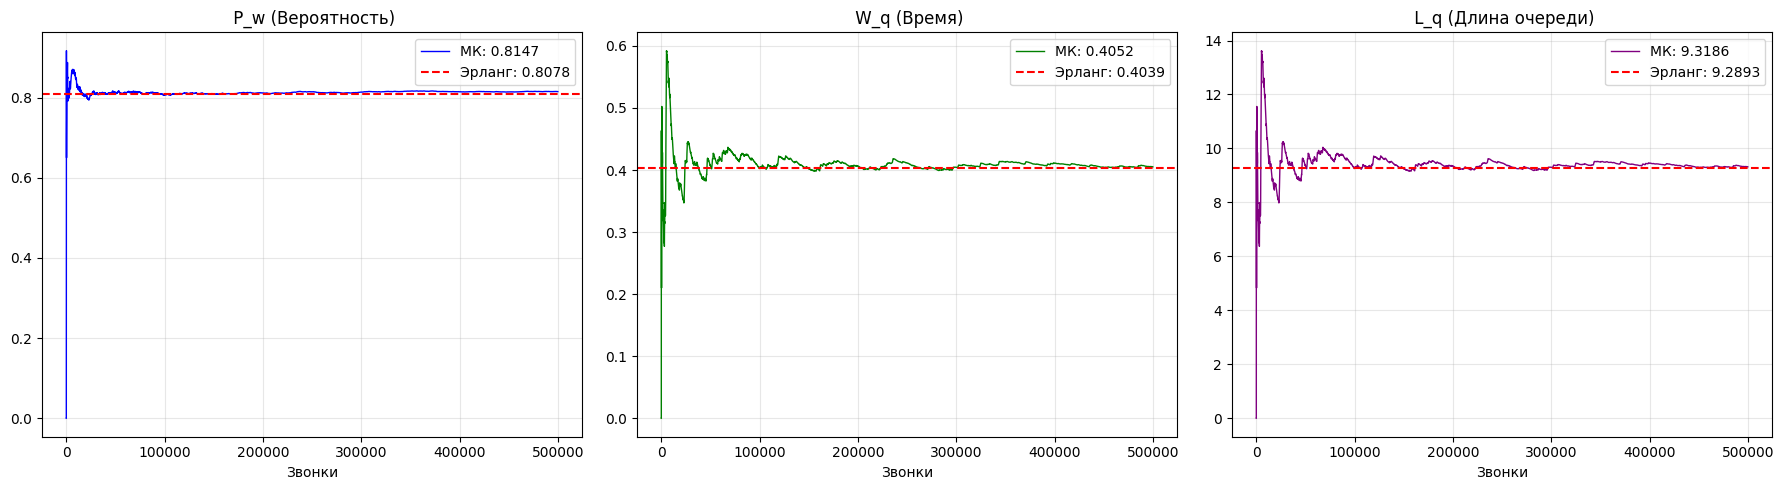

In [ ]:

indices = np.arange(1, N + 1)
running_Pw = np.cumsum(waits > 0) / indices
running_Wq = np.cumsum(waits) / indices
running_Lq = running_Wq * lam

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


plots = [
    (running_Pw, Pw_an, running_Pw[-1], "P_w (Вероятность)", "blue"),
    (running_Wq, Wq_an, running_Wq[-1], "W_q (Время)", "green"),
    (running_Lq, Lq_an, running_Lq[-1], "L_q (Длина очереди)", "purple")
]

for ax, (data, theory, final_mc, title, color) in zip(axes, plots):
    ax.plot(data, color=color, lw=1, label=f"МК: {final_mc:.4f}")
    ax.axhline(theory, color="red", ls="--", label=f"Эрланг: {theory:.4f}")
    ax.set_title(f" {title}")
    ax.set_xlabel("Звонки")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()